In [13]:
import importlib
import utils
importlib.reload(utils)

import numpy as np
import matplotlib.pyplot as plt
import time

In [14]:
ns = [5, 10, 15, 20, 25]  
steps = 10               # number of steps required for time evolution

def u(x):
    return np.sin(2*np.pi*2*x) + 0.5*np.sin(2*np.pi*7*x)

nu = 1e-3                 # diffusion coefficient 
save_every = 200          # after this many steps, take a snapshot of the function to plot on the graph
cfl = 0.1                 # controls time step relative to grid spacing. affects stability of time0-step scheme

In [15]:
def evolve_mps_timed(mps0, mpoA_list, steps, save_every=50, cutoff=1e-10, max_bond=64):
    mps = mps0.copy()
    saved = []
    bonds = []
    
    for i in range(steps):
        if i % save_every == 0:
            saved.append(mps.copy())
            bonds.append(max(mps.bond_sizes()))

        t0 = time.perf_counter()

        for mpoA in mpoA_list:
            mps = utils.step_mps(mps, mpoA, cutoff, max_bond)

        dt_step = time.perf_counter() - t0
        print(f"step {i:2d}: {dt_step:.6f} s, max bond = {max(mps.bond_sizes())}")

    # save final state
    saved.append(mps.copy())
    bonds.append(max(mps.bond_sizes()))
    return saved, bonds

# Set Up

In [16]:
times_op     = []
times_mps    = []
times_mpo    = []
times_ev_op  = []
times_ev_mps = [] 

for n in ns:
    N     = 2**n
    x     = np.linspace(0, 1, N, endpoint=False)
    dx    = x[1] - x[0] 
    dt    = cfl * dx*dx / nu 
    u0 = u(x)

    print("n = ", n)
    
    t = time.perf_counter()
    L = utils.laplacian(N, dx, "periodic", "sparse")
    A = utils.time_step(L, 1, dt, nu)
    t_op = time.perf_counter() - t

    t = time.perf_counter()
    mps0 = utils.vec_to_qtt_mps(u0, n)
    t_mps = time.perf_counter() - t

    t = time.perf_counter()
    mpoA = [utils.qtt_diffusion_mpo(n, cfl),]
    t_mpo = time.perf_counter() - t

    t = time.perf_counter()
    times, us, norms = utils.evolve_operator(u0, steps, A, dt)
    t_evolve_op = time.perf_counter() - t

    t = time.perf_counter()
    mps_saved, bond_track = evolve_mps_timed(mps0, mpoA, steps)
    t_evolve_mps = time.perf_counter() - t

    print()


    times_op.append(t_op)
    times_mps.append(t_mps)
    times_mpo.append(t_mpo)
    times_ev_op.append(t_evolve_op)
    times_ev_mps.append(t_evolve_mps)


n =  5
step  0: 0.001550 s, max bond = 12
step  1: 0.002794 s, max bond = 36
step  2: 0.042396 s, max bond = 64
step  3: 0.084259 s, max bond = 64
step  4: 0.147808 s, max bond = 64
step  5: 0.472269 s, max bond = 64
step  6: 0.703032 s, max bond = 64
step  7: 1.611123 s, max bond = 64
step  8: 3.355538 s, max bond = 64
step  9: 9.726829 s, max bond = 64

n =  10
step  0: 0.002056 s, max bond = 13
step  1: 0.012009 s, max bond = 41
step  2: 0.162943 s, max bond = 64
step  3: 0.318029 s, max bond = 64
step  4: 0.523293 s, max bond = 64
step  5: 0.474743 s, max bond = 64
step  6: 0.723105 s, max bond = 64
step  7: 1.469324 s, max bond = 64
step  8: 3.503690 s, max bond = 64
step  9: 14.025479 s, max bond = 64

n =  15
step  0: 0.002916 s, max bond = 12
step  1: 0.019403 s, max bond = 36
step  2: 0.082427 s, max bond = 64
step  3: 0.325917 s, max bond = 64
step  4: 0.483379 s, max bond = 64
step  5: 0.640557 s, max bond = 64
step  6: 0.823055 s, max bond = 64
step  7: 1.690758 s, max bond

In [17]:
mpoA = utils.qtt_diffusion_mpo(n, cfl)
print(max(mpoA.bond_sizes()))

5


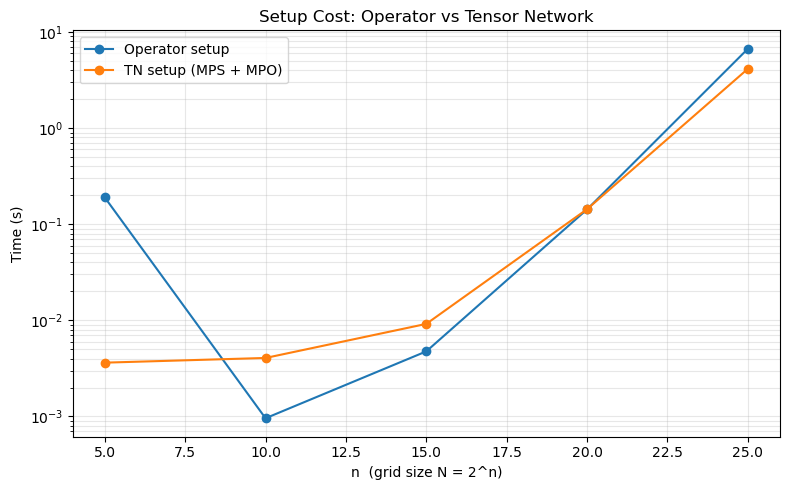

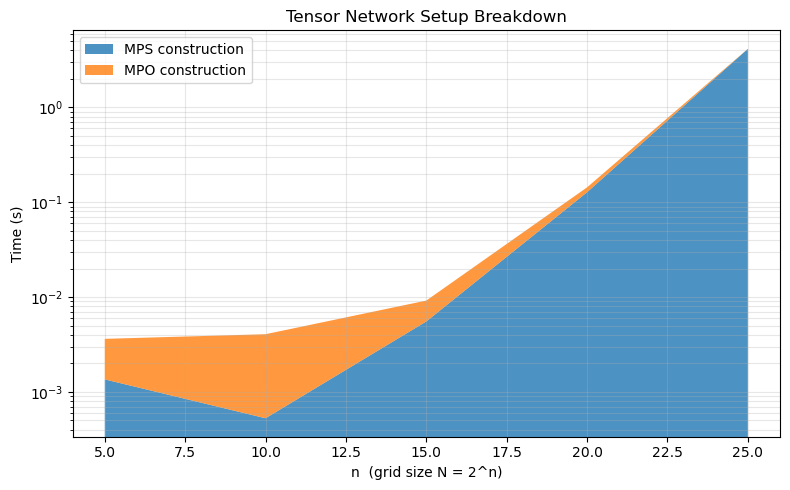

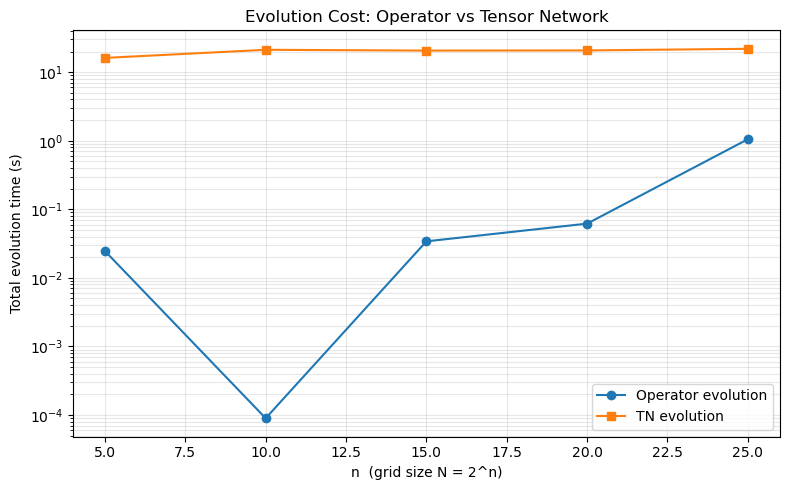

In [18]:
times_tn_setup = [m + p for m, p in zip(times_mps, times_mpo)]

# =================
# DENSE VS TN SETUP
# =================

plt.figure(figsize=(8,5))
plt.plot(ns, times_op, "o-", label="Operator setup")
plt.plot(ns, times_tn_setup, "o-", label="TN setup (MPS + MPO)")
plt.yscale("log")
plt.xlabel("n  (grid size N = 2^n)")
plt.ylabel("Time (s)")
plt.title("Setup Cost: Operator vs Tensor Network")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()



# ===================
# MPS + MPO SETUP COST
# ===================

times_mps = np.array(times_mps)
times_mpo = np.array(times_mpo)
plt.figure(figsize=(8,5))
plt.stackplot(
    ns,
    times_mps,
    times_mpo,
    labels=["MPS construction", "MPO construction"],
    alpha=0.8
)
plt.yscale("log")
plt.xlabel("n  (grid size N = 2^n)")
plt.ylabel("Time (s)")
plt.title("Tensor Network Setup Breakdown")

plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()



# =========================
# TIME EVOLUTION COMPARISON
# =========================

plt.figure(figsize=(8,5))

plt.plot(ns, times_ev_op, "o-", label="Operator evolution")
plt.plot(ns, times_ev_mps, "s-", label="TN evolution")

plt.yscale("log")
plt.xlabel("n  (grid size N = 2^n)")
plt.ylabel("Total evolution time (s)")
plt.title("Evolution Cost: Operator vs Tensor Network")

plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()